In [256]:
import pandas as pd
import sweetviz as sv
import seaborn as sns
import numpy as np
import shap
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier





In [257]:
df = pd.read_csv('Dataset.csv')
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,0
1,6.65,181.69,30733.50,5.96,343.93,257.70,17.76,35.30,4.83,0
2,7.44,194.76,34565.70,8.49,294.84,350.09,18.96,79.96,2.89,1
3,6.93,207.59,24359.47,7.22,313.82,477.06,16.50,75.04,4.90,0
4,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,0
...,...,...,...,...,...,...,...,...,...,...
3271,7.54,211.05,34359.40,8.17,365.81,447.52,18.55,60.16,3.71,1
3272,9.13,200.03,28273.60,7.50,NaN,453.87,12.86,64.18,3.03,0
3273,NaN,236.36,24873.62,9.41,300.69,479.06,13.52,46.60,5.28,0
3274,7.75,229.49,21995.07,7.75,320.44,398.54,18.20,41.06,4.32,1


In [258]:
report = sv.analyze([df, "Water potability"])
report.show_html('sv_report.html')

C:\Users\korya\AppData\Local\Programs\Python\Python310\lib\site-packages\sweetviz\dataframe_report.py:74: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  all_source_names = [cur_name for cur_name, cur_series in source_df.iteritems()]
C:\Users\korya\AppData\Local\Programs\Python\Python310\lib\site-packages\sweetviz\dataframe_report.py:109: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  filtered_series_names_in_source = [cur_name for cur_name, cur_series in source_df.iteritems()


                                             |          | [  0%]   00:00 -> (? left)

C:\Users\korya\AppData\Local\Programs\Python\Python310\lib\site-packages\sweetviz\series_analyzer_numeric.py:25: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  stats["mad"] = series.mad()
C:\Users\korya\AppData\Local\Programs\Python\Python310\lib\site-packages\sweetviz\series_analyzer_numeric.py:25: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  stats["mad"] = series.mad()
C:\Users\korya\AppData\Local\Programs\Python\Python310\lib\site-packages\sweetviz\series_analyzer_numeric.py:25: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  stats["mad"] = series.mad()
C:\Users\korya\AppData\Local\Programs\Python\Python310\lib\site-packages\sweetviz\series_analy

Report sv_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [259]:
pd.options.display.float_format = '{:.2f}'.format
df.isnull().mean() * 100

ph                14.99
Hardness           0.00
Solids             0.00
Chloramines        0.00
Sulfate           23.84
Conductivity       0.00
Organic_carbon     0.00
Trihalomethanes    4.95
Turbidity          0.00
Potability         0.00
dtype: float64

In [260]:
X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [261]:
df_filled = df.copy()
df_filled['ph'] = df_filled['ph'].fillna(df_filled['ph'].median())
df_filled['Sulfate'] = df_filled['Sulfate'].fillna(df_filled['Sulfate'].mean())
df_filled['Trihalomethanes'] = df_filled['Trihalomethanes'].fillna(df_filled['Trihalomethanes'].mean())
df_filled['ph']

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.04,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,0
1,6.65,181.69,30733.50,5.96,343.93,257.70,17.76,35.30,4.83,0
2,7.44,194.76,34565.70,8.49,294.84,350.09,18.96,79.96,2.89,1
3,6.93,207.59,24359.47,7.22,313.82,477.06,16.50,75.04,4.90,0
4,3.72,129.42,18630.06,6.64,333.78,592.89,15.18,56.33,4.50,0
...,...,...,...,...,...,...,...,...,...,...
3271,7.54,211.05,34359.40,8.17,365.81,447.52,18.55,60.16,3.71,1
3272,9.13,200.03,28273.60,7.50,333.78,453.87,12.86,64.18,3.03,0
3273,7.04,236.36,24873.62,9.41,300.69,479.06,13.52,46.60,5.28,0
3274,7.75,229.49,21995.07,7.75,320.44,398.54,18.20,41.06,4.32,1


In [262]:
imputer = KNNImputer(n_neighbors=5)

X_train_imputed_df = imputer.fit_transform(X_train)
X_test_imputed_df = imputer.transform(X_test)

scaler = StandardScaler()

feature_names = df.drop('Potability', axis=1).columns.tolist()

X_train_imputed_df = pd.DataFrame(X_train_imputed_df, columns=feature_names)
X_test_imputed_df = pd.DataFrame(X_test_imputed_df, columns=feature_names)

In [263]:
X_train_imputed_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,4.56,156.42,14400.72,9.46,325.02,483.75,7.90,54.91,4.39
1,5.92,185.93,27977.67,6.77,329.62,428.83,20.64,70.80,3.16
2,6.85,149.85,16203.09,5.73,375.72,350.34,11.72,75.50,4.94
3,5.41,143.45,19942.27,5.89,326.08,427.13,22.47,53.12,2.91
4,9.92,202.82,9973.93,6.88,337.35,333.19,23.92,71.83,4.69
...,...,...,...,...,...,...,...,...,...
2615,7.10,201.63,18093.97,8.47,361.63,348.73,8.58,49.38,4.76
2616,9.83,263.63,13345.37,6.57,295.77,462.44,12.00,76.02,3.31
2617,9.54,200.56,20044.21,7.08,303.92,335.55,16.64,71.31,3.02
2618,7.98,252.40,20197.25,2.56,350.55,454.97,12.03,69.29,5.15


In [264]:
X_test_imputed_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,6.56,241.29,56320.59,5.37,267.76,415.82,11.65,70.64,5.29
1,6.95,201.81,21709.65,6.12,352.30,417.18,19.68,49.24,4.00
2,6.57,207.74,23372.88,6.28,313.85,497.90,12.87,75.42,4.56
3,5.25,191.98,34793.85,5.82,348.93,395.71,12.57,54.97,3.49
4,8.55,206.52,10453.09,6.48,326.13,347.82,14.00,42.29,4.90
...,...,...,...,...,...,...,...,...,...
651,7.45,205.13,17537.99,8.03,396.09,318.54,13.86,93.71,3.00
652,7.74,225.06,19496.85,7.16,289.95,433.97,15.15,74.77,3.70
653,6.04,164.03,9943.64,7.72,350.76,374.79,16.67,65.54,3.92
654,7.05,240.85,19500.35,8.05,383.67,377.19,12.96,55.52,5.67


In [265]:
def new_features(dataframe):
    df = dataframe.copy()

    df['ph_normal'] = ((df['ph'] >= 6.5) & (df['ph'] <= 8.5)).astype(int)
    df['Hardness_normal'] = (df['Hardness'] < 120).astype(int)
    df['Sulfate_normal'] = (df['Sulfate'] < 250).astype(int)
    df['Chloramines_normal'] = (df['Chloramines'] < 4).astype(int)

    df['ph_squared'] = df['ph'] ** 2
    df['Hardness_squared'] = df['Hardness'] ** 2
    df['Solids_squared'] = df['Solids'] ** 2
    df['Chloramines_squared'] = df['Chloramines'] ** 2
    df['Sulfate_squared'] = df['Sulfate'] ** 2

    df['ph_Hardness'] = df['ph'] * df['Hardness']
    df['ph_Chloramines'] = df['ph'] * df['Chloramines']
    df['Hardness_Solids'] = df['Hardness'] * df['Solids']
    df['Solids_Sulfate'] = df['Solids'] * df['Sulfate']
    df['Chloramines_Sulfate'] = df['Chloramines'] * df['Sulfate']

    epsilon = 1e-6
    df['Sulfate_div_Hardness'] = df['Sulfate'] / (df['Hardness'] + epsilon)
    df['Solids_div_Conductivity'] = df['Solids'] / (df['Conductivity'] + epsilon)
    df['Organic_div_Chloramines'] = df['Organic_carbon'] / (df['Chloramines'] + epsilon)

    df['ph_deviation'] = np.abs(df['ph'] - 7.5)
    df['Hardness_deviation'] = np.abs(df['Hardness'] - 100)

    df['mineralization'] = (df['Hardness'] + df['Solids'] + df['Sulfate']) / 3
    df['treatment_score'] = (df['Chloramines'] + df['Trihalomethanes']) / 2
    df['purity_score'] = (df['Turbidity'] + df['Organic_carbon']) / 2

    df['Sulfate_minus_Hardness'] = df['Sulfate'] - df['Hardness']
    df['Chloramines_minus_pH'] = df['Chloramines'] - df['ph']

    norm_cols = ['ph_normal', 'Hardness_normal', 'Sulfate_normal', 'Chloramines_normal']
    df['normal_count'] = df[norm_cols].sum(axis=1)

    df['log_Solids'] = np.log1p(df['Solids'])
    df['log_Sulfate'] = np.log1p(df['Sulfate'])

    return df

In [266]:
X_train_fe = new_features(X_train_imputed_df)
X_test_fe = new_features(X_test_imputed_df)

In [267]:
X_train_fe

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,ph_normal,...,ph_deviation,Hardness_deviation,mineralization,treatment_score,purity_score,Sulfate_minus_Hardness,Chloramines_minus_pH,normal_count,log_Solids,log_Sulfate
0,4.56,156.42,14400.72,9.46,325.02,483.75,7.90,54.91,4.39,0,...,2.94,56.42,4960.72,32.19,6.14,168.60,4.90,0,9.58,5.79
1,5.92,185.93,27977.67,6.77,329.62,428.83,20.64,70.80,3.16,0,...,1.58,85.93,9497.74,38.79,11.90,143.69,0.86,0,10.24,5.80
2,6.85,149.85,16203.09,5.73,375.72,350.34,11.72,75.50,4.94,1,...,0.65,49.85,5576.22,40.62,8.33,225.87,-1.12,1,9.69,5.93
3,5.41,143.45,19942.27,5.89,326.08,427.13,22.47,53.12,2.91,0,...,2.09,43.45,6803.94,29.51,12.69,182.63,0.48,0,9.90,5.79
4,9.92,202.82,9973.93,6.88,337.35,333.19,23.92,71.83,4.69,0,...,2.42,102.82,3504.70,39.36,14.30,134.53,-3.04,0,9.21,5.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2615,7.10,201.63,18093.97,8.47,361.63,348.73,8.58,49.38,4.76,1,...,0.40,101.63,6219.08,28.93,6.67,160.00,1.37,1,9.80,5.89
2616,9.83,263.63,13345.37,6.57,295.77,462.44,12.00,76.02,3.31,0,...,2.33,163.63,4634.93,41.29,7.66,32.14,-3.26,0,9.50,5.69
2617,9.54,200.56,20044.21,7.08,303.92,335.55,16.64,71.31,3.02,0,...,2.04,100.56,6849.56,39.19,9.83,103.36,-2.46,0,9.91,5.72
2618,7.98,252.40,20197.25,2.56,350.55,454.97,12.03,69.29,5.15,1,...,0.48,152.40,6933.40,35.93,8.59,98.14,-5.42,2,9.91,5.86


In [268]:
X_test_fe

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,ph_normal,...,ph_deviation,Hardness_deviation,mineralization,treatment_score,purity_score,Sulfate_minus_Hardness,Chloramines_minus_pH,normal_count,log_Solids,log_Sulfate
0,6.56,241.29,56320.59,5.37,267.76,415.82,11.65,70.64,5.29,1,...,0.94,141.29,18943.21,38.00,8.47,26.48,-1.20,1,10.94,5.59
1,6.95,201.81,21709.65,6.12,352.30,417.18,19.68,49.24,4.00,1,...,0.55,101.81,7421.25,27.68,11.84,150.50,-0.83,1,9.99,5.87
2,6.57,207.74,23372.88,6.28,313.85,497.90,12.87,75.42,4.56,1,...,0.93,107.74,7964.82,40.85,8.72,106.11,-0.29,1,10.06,5.75
3,5.25,191.98,34793.85,5.82,348.93,395.71,12.57,54.97,3.49,0,...,2.25,91.98,11778.26,30.39,8.03,156.95,0.56,0,10.46,5.86
4,8.55,206.52,10453.09,6.48,326.13,347.82,14.00,42.29,4.90,0,...,1.05,106.52,3661.91,24.39,9.45,119.60,-2.07,0,9.25,5.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,7.45,205.13,17537.99,8.03,396.09,318.54,13.86,93.71,3.00,1,...,0.05,105.13,6046.40,50.87,8.43,190.96,0.57,1,9.77,5.98
652,7.74,225.06,19496.85,7.16,289.95,433.97,15.15,74.77,3.70,1,...,0.24,125.06,6670.62,40.96,9.43,64.88,-0.58,1,9.88,5.67
653,6.04,164.03,9943.64,7.72,350.76,374.79,16.67,65.54,3.92,0,...,1.46,64.03,3486.14,36.63,10.30,186.73,1.68,0,9.20,5.86
654,7.05,240.85,19500.35,8.05,383.67,377.19,12.96,55.52,5.67,1,...,0.45,140.85,6708.29,31.79,9.31,142.82,1.00,1,9.88,5.95


In [269]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_fe)

X_test_scaled = scaler.transform(X_test_fe)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train_fe.columns,
    index=X_train_fe.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

In [270]:
X_train_scaled_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,ph_normal,...,ph_deviation,Hardness_deviation,mineralization,treatment_score,purity_score,Sulfate_minus_Hardness,Chloramines_minus_pH,normal_count,log_Solids,log_Sulfate
0,-1.66,-1.20,-0.86,1.48,-0.25,0.71,-1.95,-0.73,0.55,-1.03,...,1.72,-1.21,-0.86,-0.58,-1.78,0.58,2.18,-1.05,-0.74,-0.19
1,-0.76,-0.31,0.68,-0.23,-0.12,0.02,1.91,0.28,-1.04,-1.03,...,0.37,-0.32,0.68,0.25,1.63,0.11,0.35,-1.05,0.73,-0.06
2,-0.14,-1.40,-0.65,-0.89,1.10,-0.96,-0.79,0.57,1.25,0.97,...,-0.56,-1.41,-0.65,0.48,-0.48,1.68,-0.54,0.77,-0.48,1.06
3,-1.09,-1.59,-0.23,-0.79,-0.22,0.00,2.47,-0.84,-1.37,-1.03,...,0.87,-1.61,-0.24,-0.91,2.10,0.85,0.18,-1.05,-0.02,-0.16
4,1.89,0.20,-1.36,-0.16,0.08,-1.17,2.91,0.34,0.93,-1.03,...,1.20,0.19,-1.36,0.32,3.05,-0.07,-1.40,-1.05,-1.55,0.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2615,0.03,0.16,-0.44,0.85,0.73,-0.98,-1.74,-1.07,1.02,0.97,...,-0.81,0.16,-0.44,-0.98,-1.46,0.42,0.58,0.77,-0.23,0.73
2616,1.83,2.03,-0.98,-0.36,-1.02,0.44,-0.70,0.60,-0.85,-1.03,...,1.11,2.04,-0.97,0.57,-0.88,-2.02,-1.50,-1.05,-0.90,-1.00
2617,1.64,0.13,-0.22,-0.03,-0.81,-1.14,0.70,0.31,-1.21,-1.03,...,0.82,0.13,-0.22,0.30,0.41,-0.66,-1.14,-1.05,-0.01,-0.76
2618,0.61,1.69,-0.20,-2.90,0.43,0.35,-0.69,0.18,1.52,0.97,...,-0.73,1.70,-0.19,-0.11,-0.33,-0.76,-2.47,2.60,0.01,0.47


In [271]:
X_test_scaled_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,ph_normal,...,ph_deviation,Hardness_deviation,mineralization,treatment_score,purity_score,Sulfate_minus_Hardness,Chloramines_minus_pH,normal_count,log_Solids,log_Sulfate
0,-0.33,1.35,3.89,-1.12,-1.77,-0.14,-0.81,0.27,1.71,0.97,...,-0.27,1.36,3.89,0.15,-0.40,-2.13,-0.57,0.77,2.28,-1.86
1,-0.07,0.16,-0.03,-0.64,0.48,-0.12,1.62,-1.08,0.04,0.97,...,-0.66,0.16,-0.03,-1.14,1.59,0.24,-0.41,0.77,0.17,0.51
2,-0.32,0.34,0.16,-0.54,-0.54,0.88,-0.44,0.57,0.76,0.97,...,-0.28,0.34,0.16,0.51,-0.25,-0.61,-0.16,0.77,0.33,-0.49
3,-1.19,-0.13,1.45,-0.84,0.39,-0.39,-0.53,-0.72,-0.62,-1.03,...,1.03,-0.13,1.45,-0.80,-0.66,0.36,0.22,-1.05,1.21,0.43
4,0.98,0.31,-1.30,-0.41,-0.22,-0.99,-0.10,-1.52,1.20,-1.03,...,-0.16,0.31,-1.30,-1.55,0.18,-0.35,-0.96,-1.05,-1.44,-0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,0.26,0.26,-0.50,0.57,1.64,-1.35,-0.14,1.72,-1.25,0.97,...,-1.16,0.26,-0.49,1.77,-0.42,1.01,0.23,0.77,-0.30,1.52
652,0.45,0.86,-0.28,0.02,-1.18,0.09,0.25,0.53,-0.34,0.97,...,-0.97,0.87,-0.28,0.52,0.17,-1.39,-0.29,0.77,-0.07,-1.17
653,-0.68,-0.97,-1.36,0.37,0.44,-0.65,0.71,-0.06,-0.06,-1.03,...,0.25,-0.98,-1.36,-0.02,0.68,0.93,0.73,-1.05,-1.56,0.47
654,-0.01,1.34,-0.28,0.58,1.31,-0.62,-0.41,-0.69,2.19,0.97,...,-0.76,1.35,-0.27,-0.63,0.10,0.09,0.42,0.77,-0.07,1.25


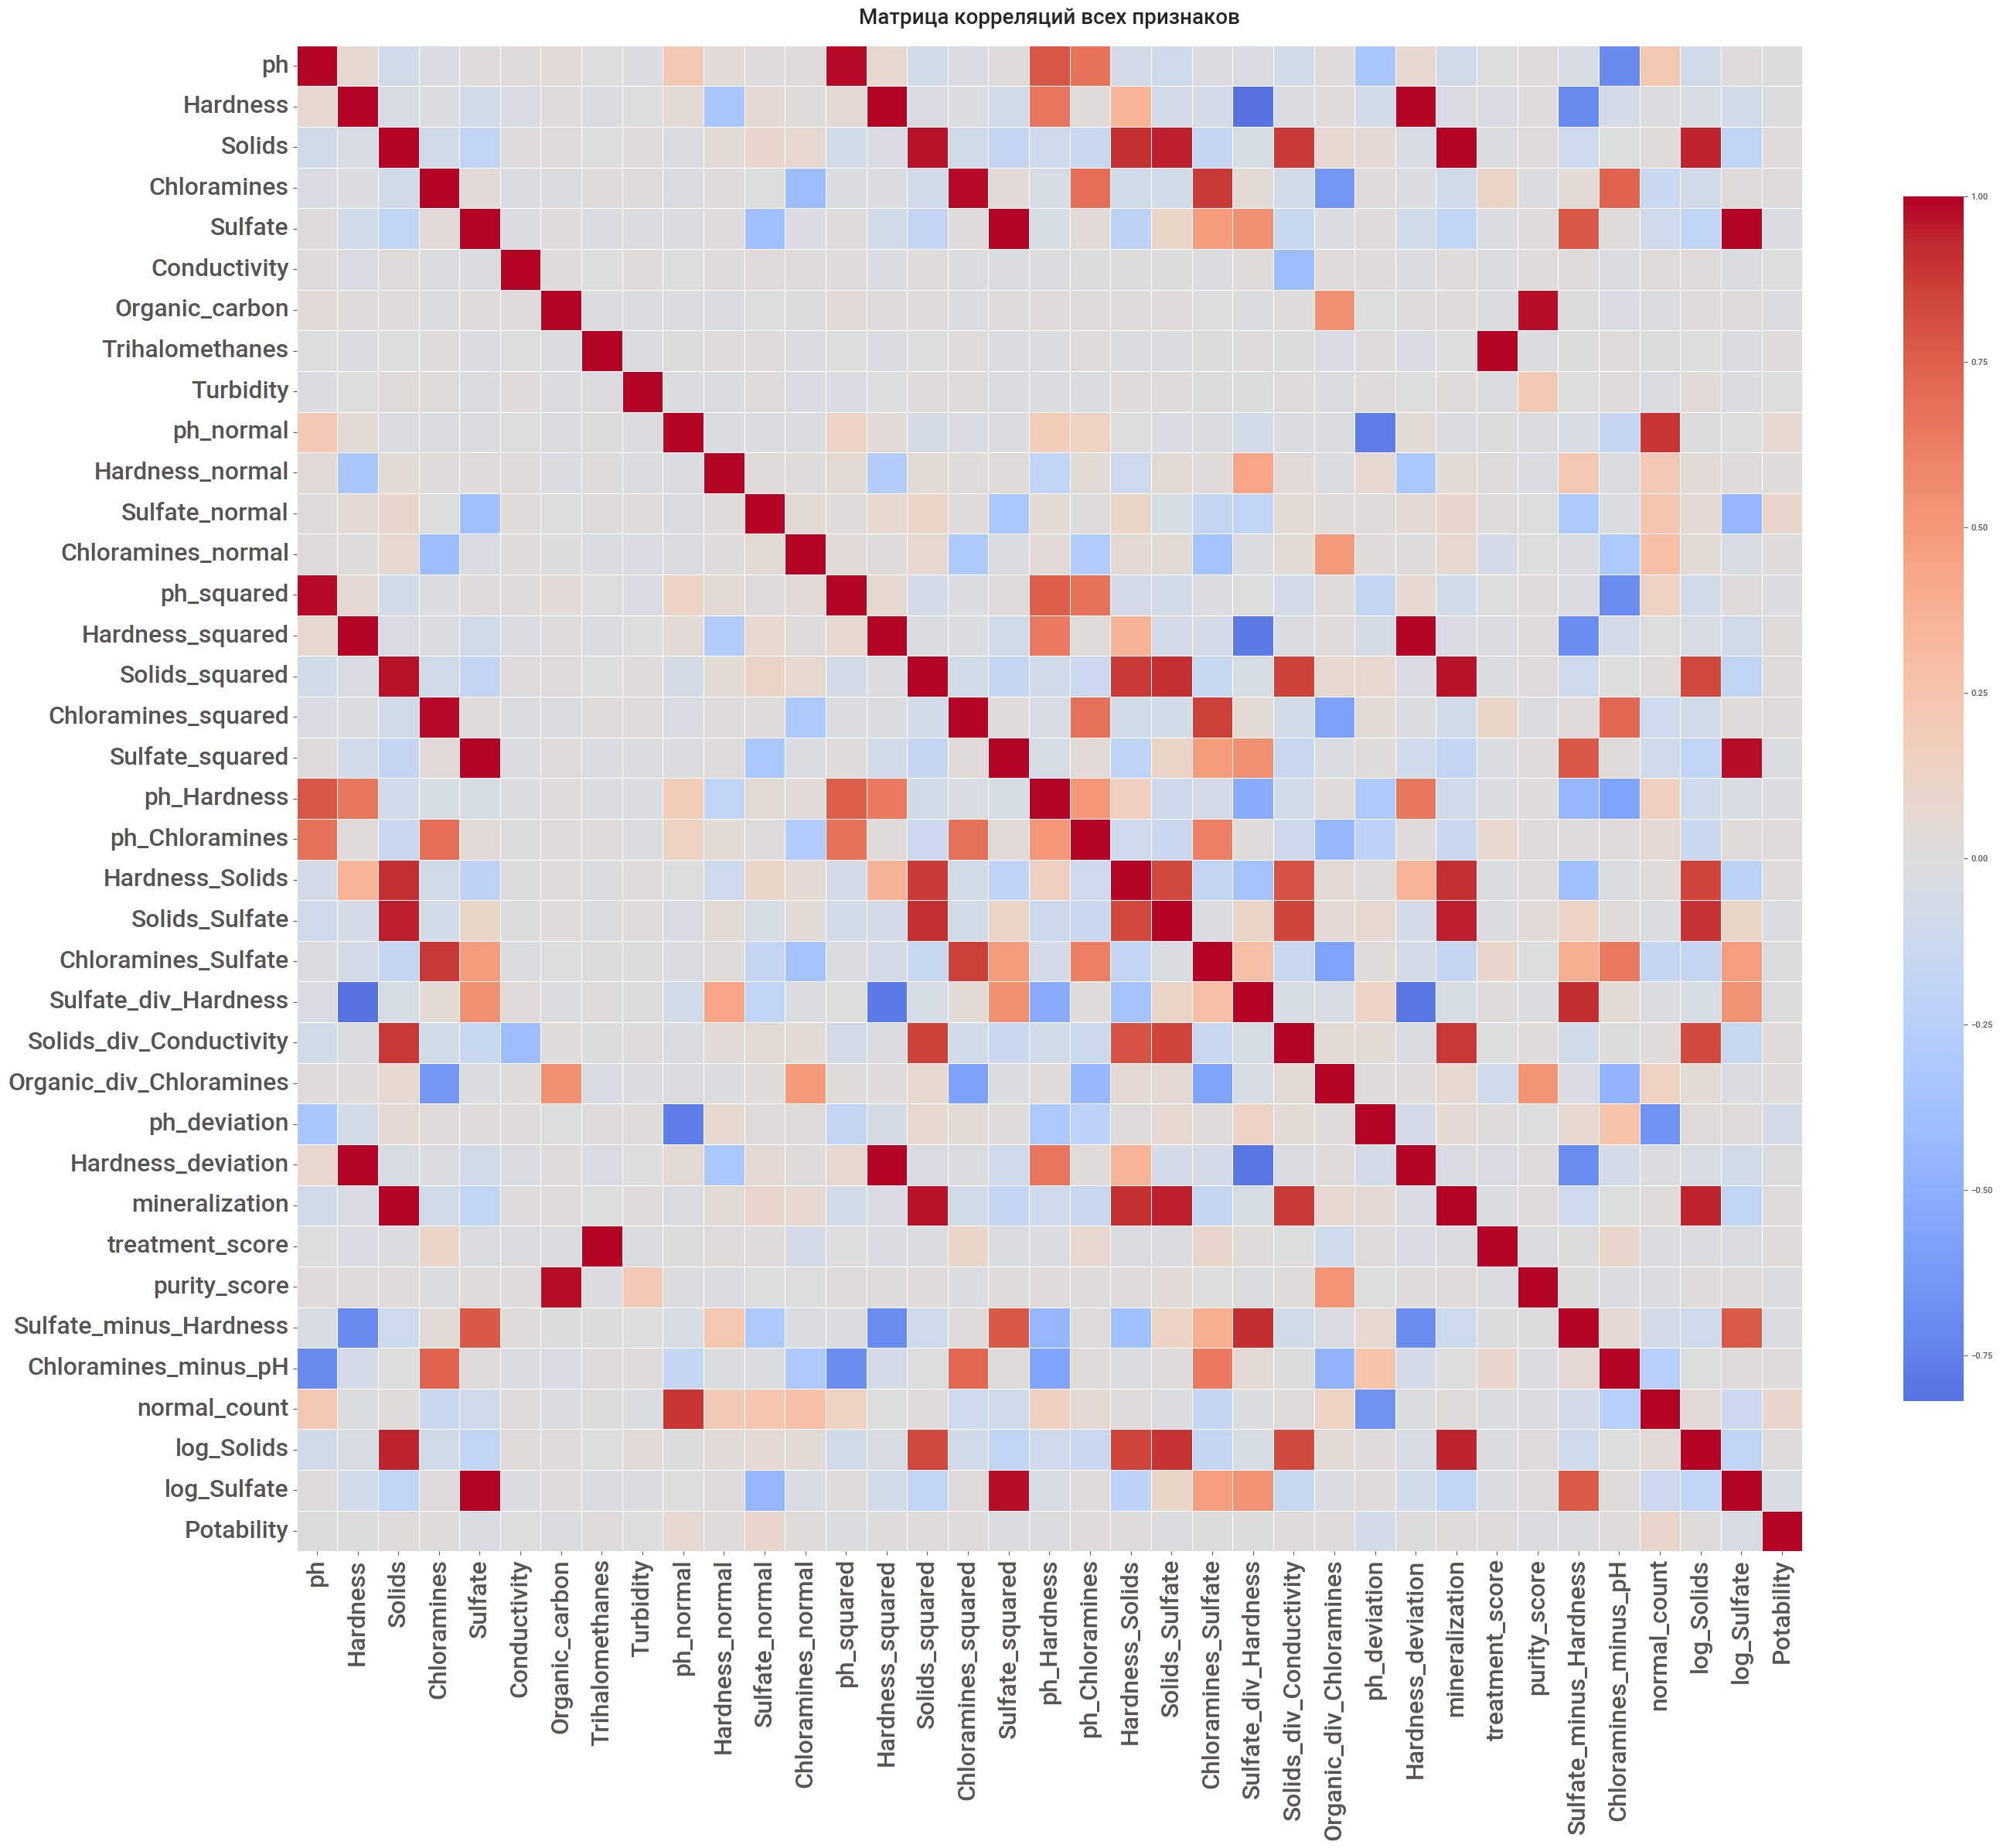


Положительные корреляции:
 1. normal_count                    0.0916
 2. Sulfate_normal                  0.0897
 3. ph_normal                       0.0680
 4. ph_Chloramines                  0.0338
 5. Solids_squared                  0.0255

Отрицательные корреляции:
 1. Organic_carbon                  -0.0217
 2. purity_score                    -0.0226
 3. Sulfate                         -0.0263
 4. log_Sulfate                     -0.0426
 5. ph_deviation                    -0.0771


In [272]:
# Создаем DataFrame с целевой переменной
train_with_target = X_train_scaled_df.copy()
train_with_target['Potability'] = y_train.values

# Рассчитываем корреляции
correlation_matrix = train_with_target.corr()

# 1. УВЕЛИЧИВАЕМ РАЗМЕР (правильный порядок)
plt.figure(figsize=(30, 24))  # Увеличил размер и ПЕРЕНЕС ДО heatmap

# Создаем heatmap
sns.heatmap(
    correlation_matrix,
    annot=False,  # True если хотите цифры
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    xticklabels=True,
    yticklabels=True
)

plt.title('Матрица корреляций всех признаков', fontsize=20, pad=20)
plt.xticks(fontsize=23)
plt.yticks(fontsize=23)
plt.tight_layout()
plt.show()


target_corr = correlation_matrix['Potability'].drop('Potability').sort_values(ascending=False)

print("\nПоложительные корреляции:")
for i, (feature, corr) in enumerate(target_corr.head(5).items(), 1):
    print(f"{i:2}. {feature:30}  {corr:.4f}")

print("\nОтрицательные корреляции:")
for i, (feature, corr) in enumerate(target_corr.tail(5).items(), 1):
    print(f"{i:2}. {feature:30}  {corr:.4f}")


C:\Users\korya\AppData\Local\Temp\ipykernel_35516\1051714705.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nan_counts.index, y=nan_counts.values, palette='viridis')


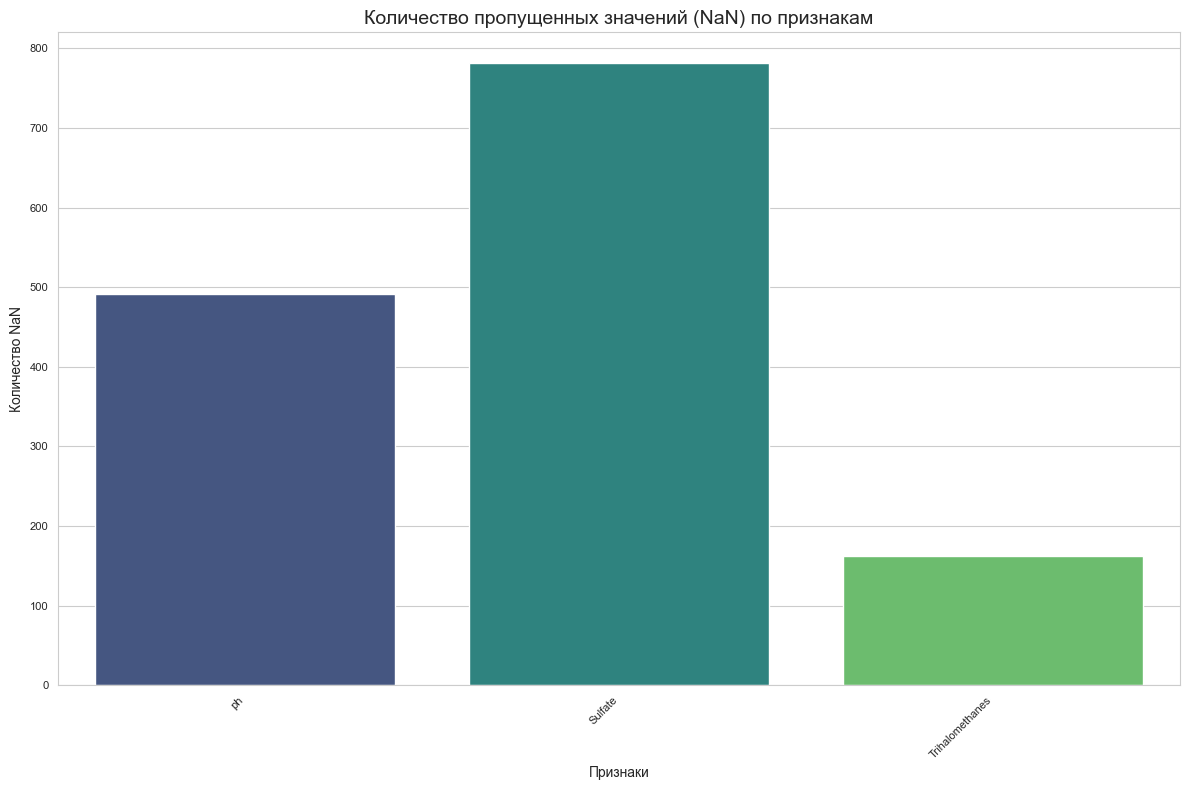

Общее количество NaN в датасете: 1434

NaN по столбцам:
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

Процент пропусков в данных: 4.38%


In [283]:
nan_counts = df.isnull().sum()
nan_counts = nan_counts[nan_counts > 0]

sns.barplot(x=nan_counts.index, y=nan_counts.values, palette='viridis')
plt.title('Количество пропущенных значений (NaN) по признакам', fontsize=14)
plt.xlabel('Признаки')
plt.ylabel('Количество NaN')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Общее количество NaN в датасете:", df.isnull().sum().sum())
print("\nNaN по столбцам:")
print(nan_counts)
print(f"\nПроцент пропусков в данных: {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%")

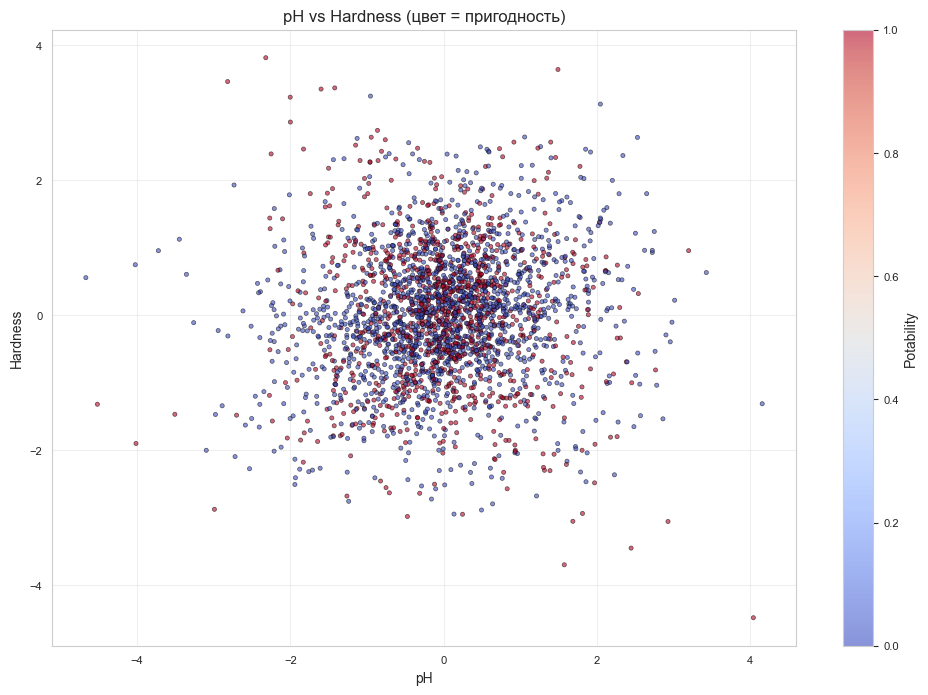

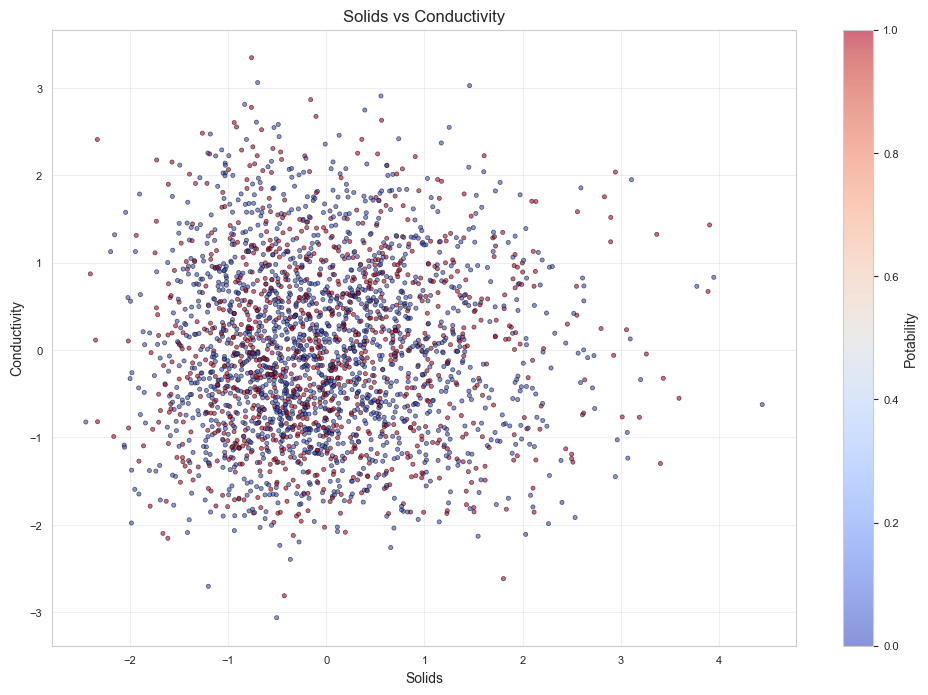

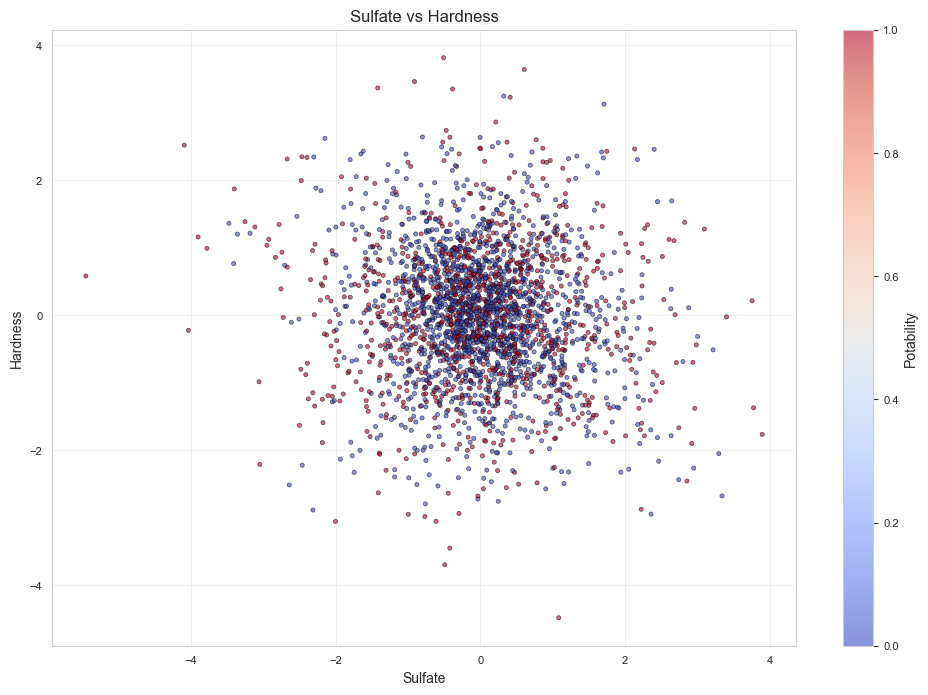

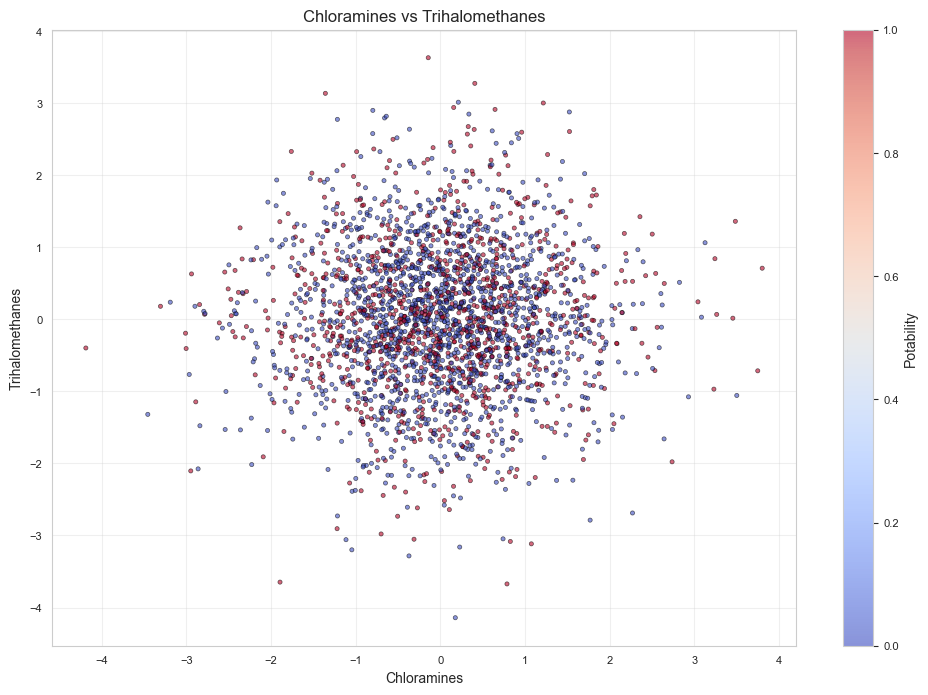

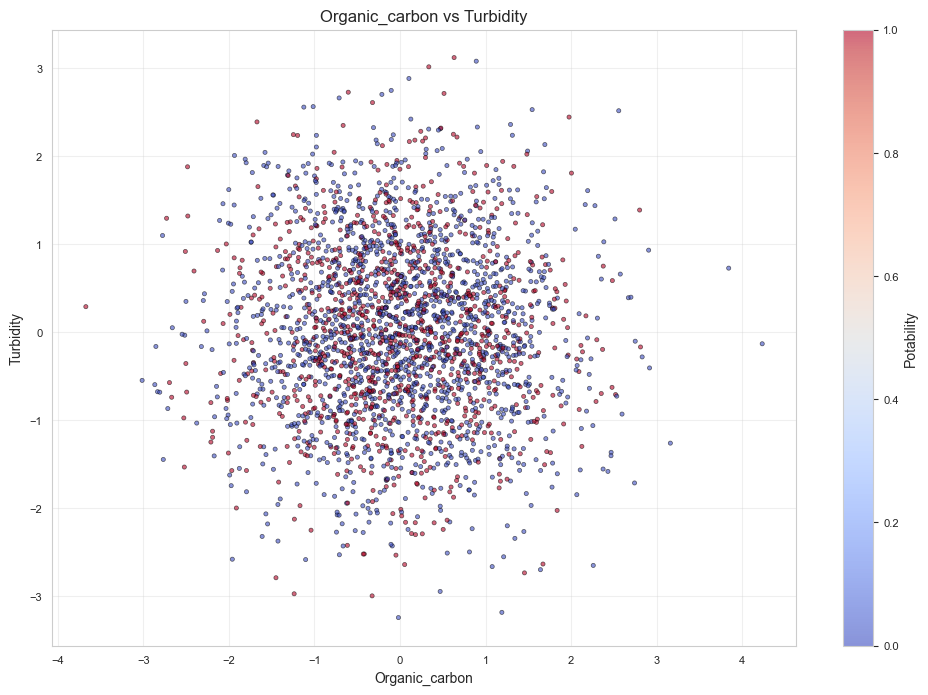

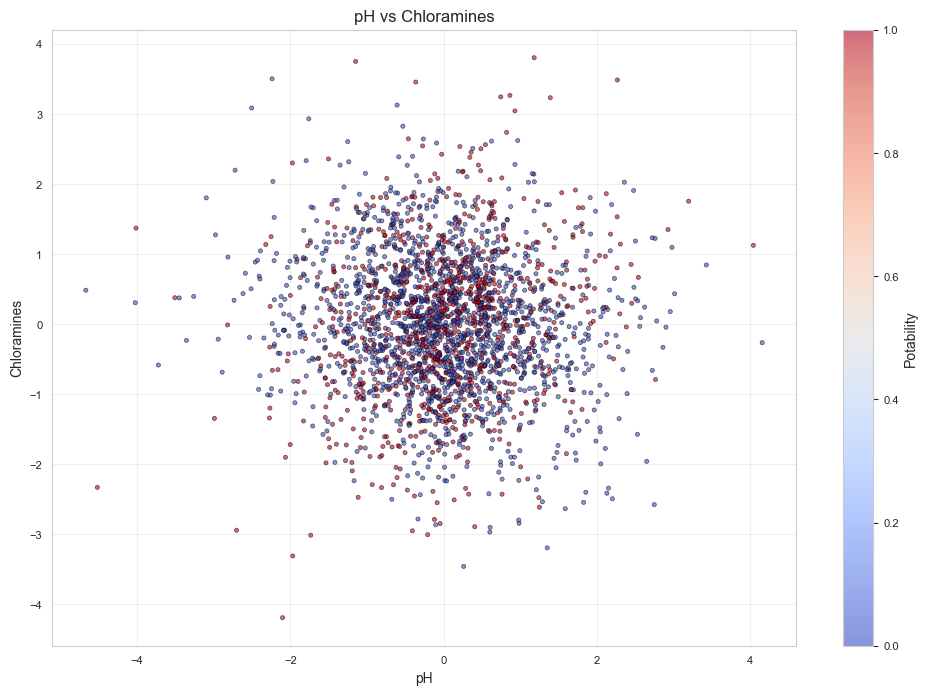

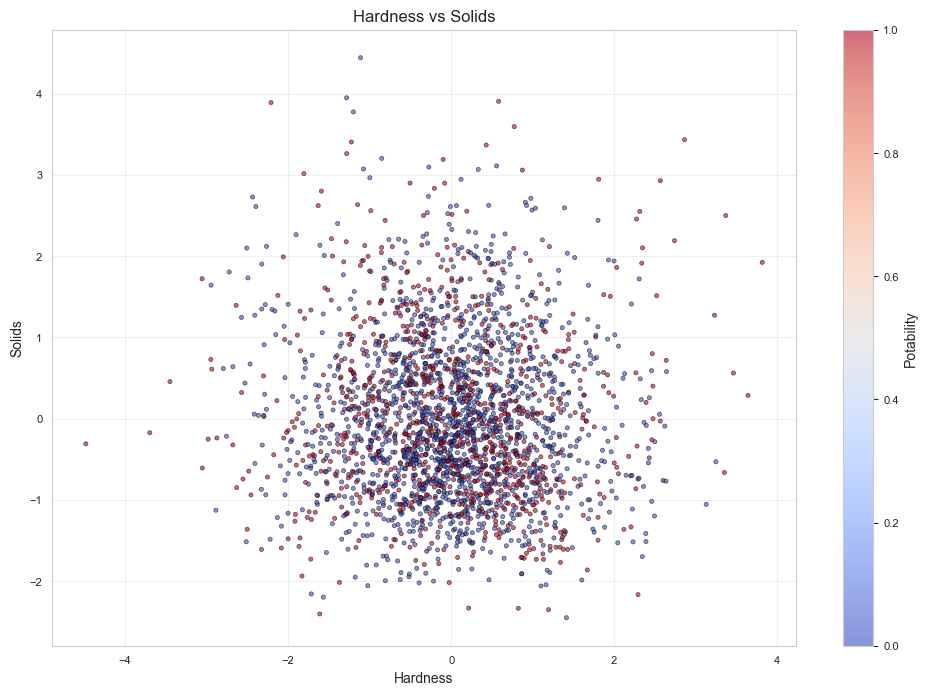

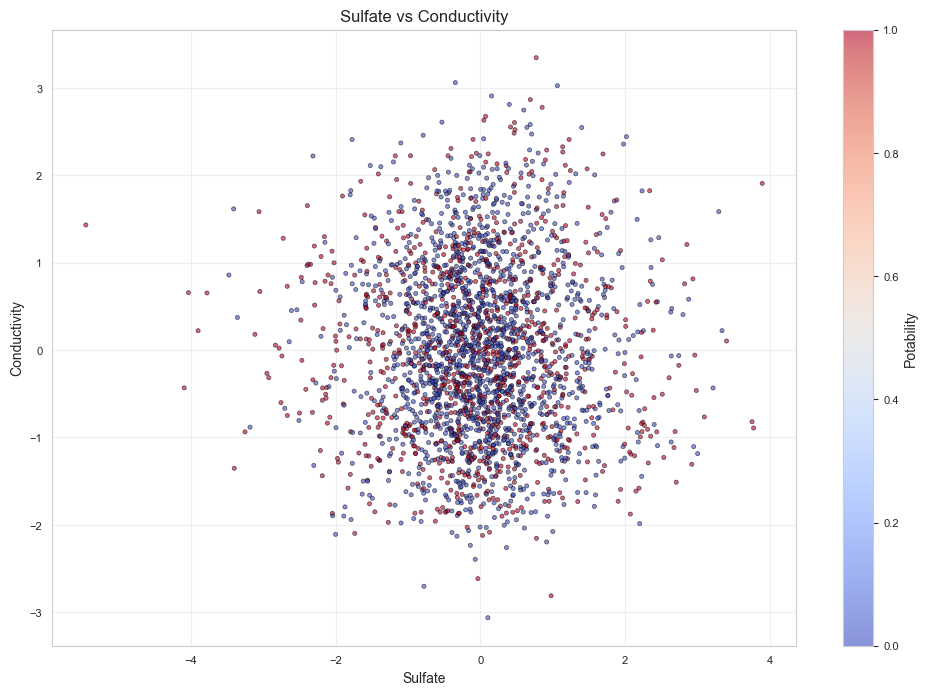

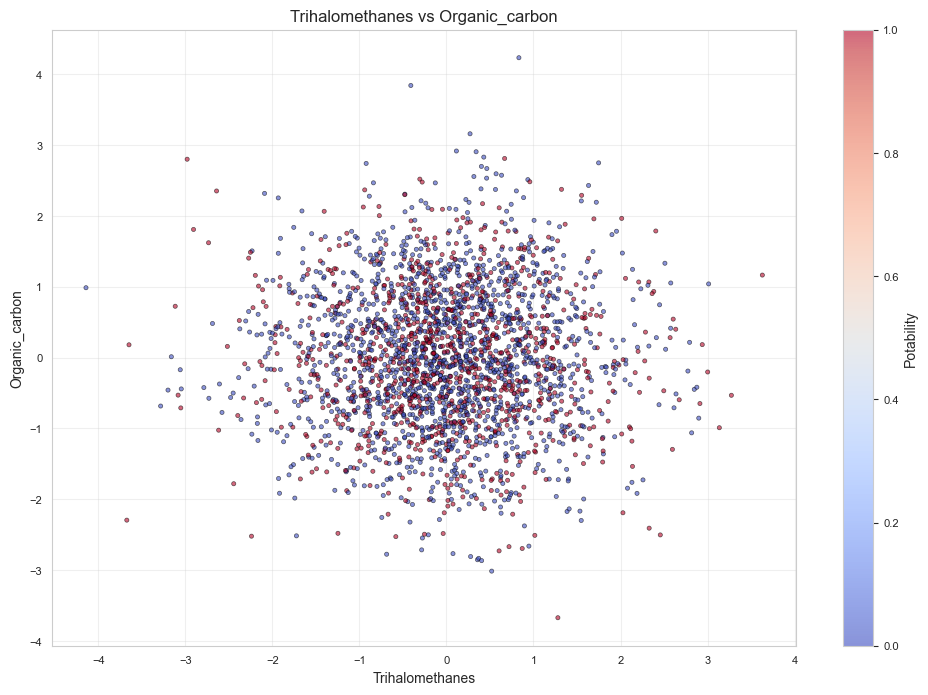

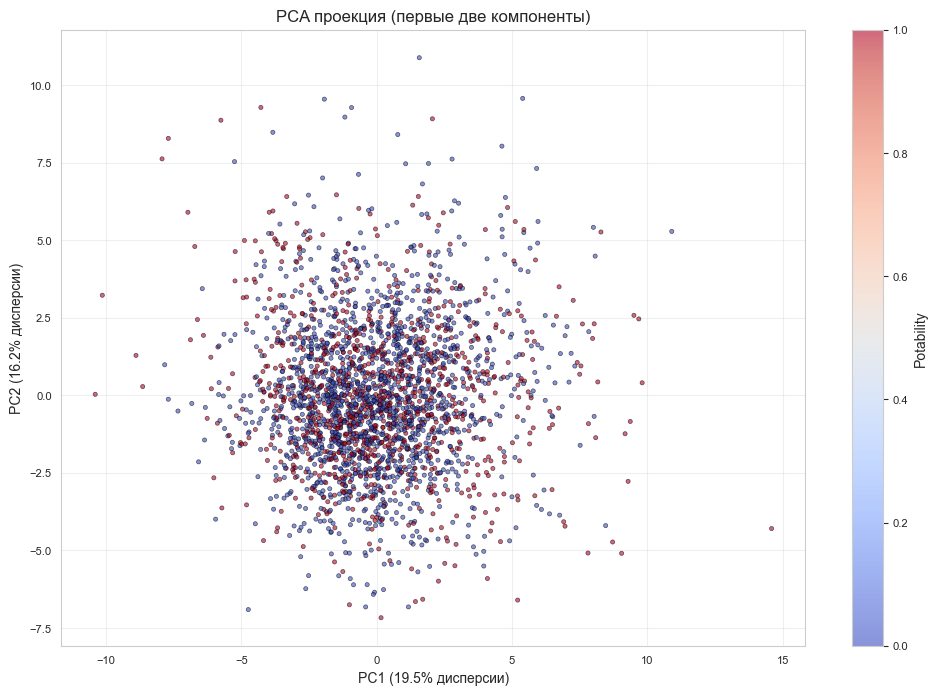

Объясненная дисперсия PC1: 19.52%
Объясненная дисперсия PC2: 16.15%
Суммарно: 35.67%


In [274]:

plot_df = X_train_scaled_df.copy()
plot_df['Potability'] = y_train.values

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


plt.figure()
scatter = plt.scatter(
    plot_df['ph'], plot_df['Hardness'],
    c=plot_df['Potability'], cmap='coolwarm', alpha=0.6,
    edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Potability')
plt.xlabel('pH')
plt.ylabel('Hardness')
plt.title('pH vs Hardness (цвет = пригодность)')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Solids vs Conductivity
plt.figure()
scatter = plt.scatter(
    plot_df['Solids'], plot_df['Conductivity'],
    c=plot_df['Potability'], cmap='coolwarm', alpha=0.6,
    edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Potability')
plt.xlabel('Solids')
plt.ylabel('Conductivity')
plt.title('Solids vs Conductivity')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Sulfate vs Hardness
plt.figure()
scatter = plt.scatter(
    plot_df['Sulfate'], plot_df['Hardness'],
    c=plot_df['Potability'], cmap='coolwarm', alpha=0.6,
    edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Potability')
plt.xlabel('Sulfate')
plt.ylabel('Hardness')
plt.title('Sulfate vs Hardness')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Chloramines vs Trihalomethanes
plt.figure()
scatter = plt.scatter(
    plot_df['Chloramines'], plot_df['Trihalomethanes'],
    c=plot_df['Potability'], cmap='coolwarm', alpha=0.6,
    edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Potability')
plt.xlabel('Chloramines')
plt.ylabel('Trihalomethanes')
plt.title('Chloramines vs Trihalomethanes')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Organic_carbon vs Turbidity
plt.figure()
scatter = plt.scatter(
    plot_df['Organic_carbon'], plot_df['Turbidity'],
    c=plot_df['Potability'], cmap='coolwarm', alpha=0.6,
    edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Potability')
plt.xlabel('Organic_carbon')
plt.ylabel('Turbidity')
plt.title('Organic_carbon vs Turbidity')
plt.grid(True, alpha=0.3)
plt.show()

# 6. pH vs Chloramines
plt.figure()
scatter = plt.scatter(
    plot_df['ph'], plot_df['Chloramines'],
    c=plot_df['Potability'], cmap='coolwarm', alpha=0.6,
    edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Potability')
plt.xlabel('pH')
plt.ylabel('Chloramines')
plt.title('pH vs Chloramines')
plt.grid(True, alpha=0.3)
plt.show()

# 7. Hardness vs Solids
plt.figure()
scatter = plt.scatter(
    plot_df['Hardness'], plot_df['Solids'],
    c=plot_df['Potability'], cmap='coolwarm', alpha=0.6,
    edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Potability')
plt.xlabel('Hardness')
plt.ylabel('Solids')
plt.title('Hardness vs Solids')
plt.grid(True, alpha=0.3)
plt.show()

# 8. Sulfate vs Conductivity
plt.figure()
scatter = plt.scatter(
    plot_df['Sulfate'], plot_df['Conductivity'],
    c=plot_df['Potability'], cmap='coolwarm', alpha=0.6,
    edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Potability')
plt.xlabel('Sulfate')
plt.ylabel('Conductivity')
plt.title('Sulfate vs Conductivity')
plt.grid(True, alpha=0.3)
plt.show()

# 9. Trihalomethanes vs Organic_carbon
plt.figure()
scatter = plt.scatter(
    plot_df['Trihalomethanes'], plot_df['Organic_carbon'],
    c=plot_df['Potability'], cmap='coolwarm', alpha=0.6,
    edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Potability')
plt.xlabel('Trihalomethanes')
plt.ylabel('Organic_carbon')
plt.title('Trihalomethanes vs Organic_carbon')
plt.grid(True, alpha=0.3)
plt.show()

# 10. PCA проекция
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled_df)

plt.figure()
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_train, cmap='coolwarm', alpha=0.6,
    edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Potability')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)')
plt.title('PCA проекция (первые две компоненты)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Объясненная дисперсия PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Объясненная дисперсия PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Суммарно: {pca.explained_variance_ratio_[:2].sum():.2%}")

In [275]:
model = CatBoostClassifier(
    iterations=1000,               # количество деревьев
    learning_rate=0.1,             # скорость обучения
    depth=6,                       # глубина деревьев
    loss_function='Logloss',       # функция потерь для бинарной классификации
    eval_metric='AUC',             # метрика для оценки на валидации
    random_seed=42,                # для воспроизводимости (ответ на вопрос смысла жизни и всего)
    verbose=100,                   # вывод каждые 100 итераций
    early_stopping_rounds=50,      # остановка если нет улучшений
    class_weights=[1, 2],          # веса классов (пригодная вода важнее в 2 раза)
    task_type='CPU'                # тип устройства для обучения
)

# Обучение модели
model.fit(
    X_train_scaled_df, y_train,
    eval_set=(X_test_scaled_df, y_test),    # валидационная выборка
    plot=True,                              # визуализация процесса обучения
    use_best_model=True                     # использование лучшей модели
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.5392578	best: 0.5392578 (0)	total: 4.24ms	remaining: 4.24s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6607910156
bestIteration = 27

Shrink model to first 28 iterations.


Accuracy: 0.5549
ROC-AUC: 0.6608

Classification Report:
              precision    recall  f1-score   support

 Непригодная       0.73      0.43      0.54       400
   Пригодная       0.46      0.75      0.57       256

    accuracy                           0.55       656
   macro avg       0.59      0.59      0.55       656
weighted avg       0.62      0.55      0.55       656



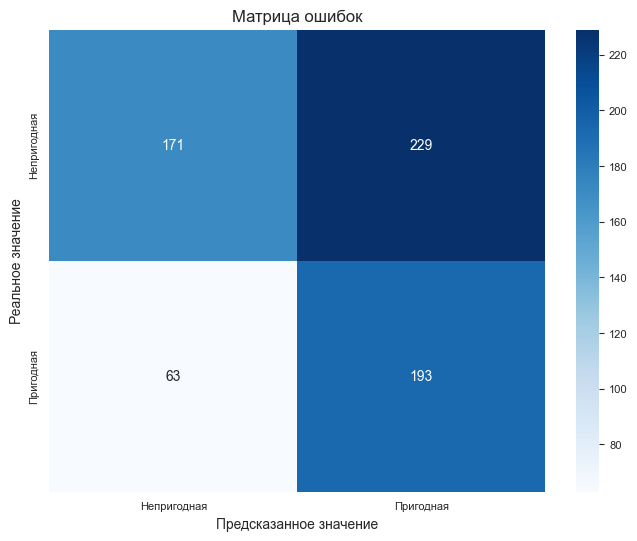

In [276]:
y_pred = model.predict(X_test_scaled_df)# Предсказание на тестовой выборке
y_pred_proba = model.predict_proba(X_test_scaled_df)[:, 1]


accuracy = accuracy_score(y_test, y_pred)# Расчет метрик
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Непригодная', 'Пригодная']))


plt.figure(figsize=(8, 6))# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Непригодная', 'Пригодная'],
            yticklabels=['Непригодная', 'Пригодная'])
plt.title('Матрица ошибок')
plt.ylabel('Реальное значение')
plt.xlabel('Предсказанное значение')
plt.show()

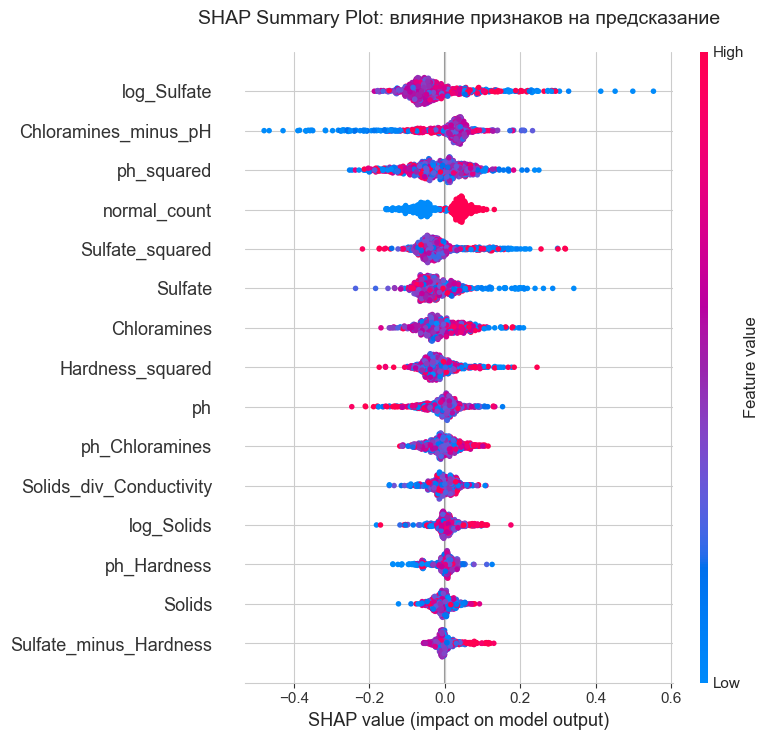

In [277]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_scaled_df)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

    plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_scaled_df,
    feature_names=X_test_scaled_df.columns,
    show=False,
    max_display=15
)
plt.title('SHAP Summary Plot: влияние признаков на предсказание', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [278]:
df_scaled = X_train_scaled_df.copy()
df_scaled['Potability'] = y_train.values
df_scaled.to_csv('water_potability_scaled.csv', index=False)